<img src="https://dauphine.psl.eu/fileadmin/_processed_/9/2/csm_damier_logo_Dauphine_f7b37a1ff2.jpg" width="200" style="vertical-align:middle" /> <h1>Master 222: Introduction to Python - Session 5</h1>





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zaltarba/PSL_python_for_finance/blob/main/python_session_5.ipynb)

# Introduction to yfinance

### What is yfinance?

`yfinance` stands for Yahoo Finance, and the `yfinance` library in Python allows you to access financial data from Yahoo! Finance. This can include stock prices, historical data, financial statements, and much more.

### Why use `yfinance`?

If you're interested in financial analysis, algorithmic trading, or just want to understand how the stock market behaves over time, `yfinance` is a great tool to start with. With just a few lines of Python code, you can retrieve vast amounts of financial data.

### Getting Started

Start by importing the library:
```
import yfinance as yf
```
Fetching Data:

You can fetch data for a specific stock or index. Here's how to get the historical data for Apple Inc. (AAPL) for the past month:
```
data = yf.download("AAPL", period="1mo")
print(data)
```

- Fetch the data for AAPL
- Using matplotlib.pyplot, plot the closing prices



In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt


/tmp/ipykernel_1364/1839859804.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed


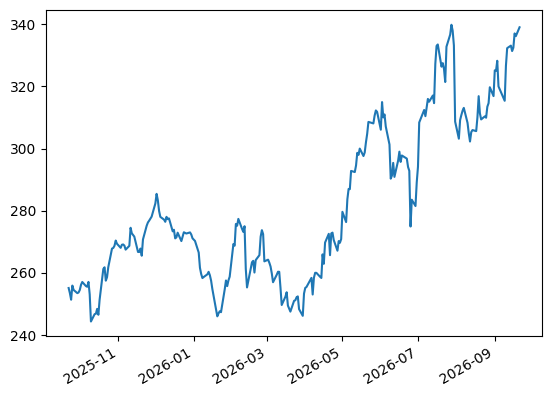

In [ ]:
data=yf.download('AAPL', period='1y')
plt.plot(data['Close'])
plt.gcf().autofmt_xdate()
plt.show()

**Exercise: Analyzing Historical Stock Prices**
> Context:
You are a financial analyst at an investment firm. You have been given a dataset containing historical stock prices of several companies over the past decade. Your task is to clean, analyze, and visualize the data to help the firm make informed investment decisions.

> Dataset:
The dataset contains the following columns: 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'.


**Data Loading and Inspection**:

- Fetch the historical stock price data for 'AAPL'.
- Display the first 10 rows of the dataset.
- Check for any missing values in the dataset.

**Data Cleaning**:

- Handle any missing values: You can either fill them using methods such as forward fill, backward fill, or interpolation, or you can choose to drop rows with missing values.
- Convert the 'Date' column to a datetime format if it isn't already..

**Data Transformation**:

- Make the 'Date' column the index of the DataFrame to facilitate time series analysis.
- Compute a new column 'Price_Average', which is the arithmetic mean of the 'High' and 'Low' prices for each trading day.

**Data Analysis**:

- Determine the specific date when the trading volume for Apple Inc. was at its peak.
- Compute the monthly average of the 'Close' price to understand monthly performance trends.

**Data Aggregation**:

- Calculate the total trading volume and average closing price for each company over the period.

**File I/O**:

- Save the cleaned and transformed dataset to a new CSV file.
- Save the plots as image files.

**Bonus**:

- Use a simple linear regression model to attempt predictions of future stock prices based on historical data. This will provide a rudimentary forecast which can be enhanced with more complex models.
- Implement a basic moving average trading strategy. For instance, consider using a 50-day and a 200-day moving average. Generate buy signals when the 50-day moving average crosses above the 200-day moving average, and sell signals when it crosses below. Backtest this strategy to gauge its historical performance.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
tickers=['AAPL','MSFT','TSLA','NVO','MC.PA','OR.PA','NVDA','BNP.PA','TTE.PA']
data=yf.download(tickers,period='10y')
data.head(10)

/tmp/ipykernel_1364/4008341938.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers,period='10y')
[*********************100%***********************]  9 of 9 completed


Price           Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-22  26.211939  27.494652  129.032822  51.342262  1.595125  18.039003   
2016-09-23  25.775164  27.294117  128.656250  50.995964  1.593408  17.765863   
2016-09-26  25.814035  26.401846  126.982658  50.525345  1.578443  17.587727   
2016-09-27  25.862057  26.265244  127.066338  51.457687  1.632416  17.358131   
2016-09-28  26.058727  26.515192  127.526581  51.528748  1.638304  17.314594   
2016-09-29  25.653955  26.393122  126.104027  50.969330  1.653514  16.546635   
2016-09-30  25.852909  26.605291  127.024506  51.146927  1.680991  16.463509   
2016-10-03  25.731705  26.515192  127.191856  50.987087  1.679273  16.277454   
2016-10-04  25.841475  26.756422  131.041107  50.827240  1.675593  16.083492   
2016-10-05  25.852909  27.669044  130.748230  51.182426  1.673876  16.435799   

Price                                              High  ...       Open  \
Ticker           OR.PA       TSLA     TTE.PA       AAPL  ...     TTE.PA   
Date                                                     ...              
2016-09-22  144.866989  13.762000  23.901093  26.285118  ...  23.265469   
2016-09-23  144.269409  13.830000  23.612429  26.250830  ...  23.798397   
2016-09-26  142.263306  13.932667  23.165545  25.930666  ...  23.373718   
2016-09-27  143.031601  13.720667  22.968372  25.882639  ...  23.362728   
2016-09-28  143.799896  13.751333  23.081043  26.216521  ...  23.097943   
2016-09-29  143.116989  13.380000  24.038769  26.024427  ...  24.210595   
2016-09-30  143.501114  13.602000  23.757082  25.926088  ...  23.678211   
2016-10-03  143.629181  14.246667  23.844402  25.852910  ...  23.802150   
2016-10-04  145.421890  14.094000  24.286644  26.141052  ...  23.886656   
2016-10-05  141.879166  13.897333  24.264109  25.992407  ...  23.990877   

Price            Volume                                                 \
Ticker             AAPL     BNP.PA      MC.PA        MSFT         NVDA   
Date                                                                     
2016-09-22  124296000.0  5030250.0   845731.0  19822200.0  308732000.0   
2016-09-23  209924800.0  3697080.0   534423.0  19955300.0  276132000.0   
2016-09-26  119477600.0  3919481.0   524416.0  21688700.0  230040000.0   
2016-09-27   98429600.0  4208318.0   577866.0  28065100.0  402752000.0   
2016-09-28  118564400.0  3447639.0   435720.0  20536400.0  319788000.0   
2016-09-29  143548000.0  2463934.0   479949.0  25463500.0  336684000.0   
2016-09-30  145516400.0  6379925.0   743922.0  29910800.0  429932000.0   
2016-10-03   86807200.0  1773168.0   324385.0  19189500.0  242596000.0   
2016-10-04  118947200.0  2739790.0  1109267.0  20085900.0  281624000.0   
2016-10-05   85812400.0  5192510.0   614540.0  16726400.0  305440000.0   

Price                                                    
Ticker             NVO     OR.PA        TSLA     TTE.PA  
Date                                                     
2016-09-22   4693000.0  665852.0  35743500.0  7651893.0  
2016-09-23   7747800.0  353632.0  43578000.0  5818834.0  
2016-09-26   3881400.0  456439.0  35916000.0  6268784.0  
2016-09-27   6298400.0  433051.0  50598000.0  6137801.0  
2016-09-28   5844600.0  382823.0  31326000.0  4402576.0  
2016-09-29   9584200.0  354474.0  40905000.0  7934813.0  
2016-09-30  11301000.0  580712.0  38794500.0  7665326.0  
2016-10-03   7161800.0  343323.0  89998500.0  4144437.0  
2016-10-04  10758800.0  549128.0  53122500.0  5844520.0  
2016-10-05  10034000.0  487257.0  28162500.0  5933056.0  

[10 rows x 45 columns]

In [ ]:
data['Close'].isna().sum()

,0
Ticker,
AAPL,72
BNP.PA,24
MC.PA,24
MSFT,72
NVDA,72
NVO,72
OR.PA,24
TSLA,72
TTE.PA,24


In [ ]:
data=data.ffill()
data.isna().any()

Price   Ticker
Close   AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
High    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Low     AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Open    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Volume  AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
dtype: bool

In [ ]:
print(data.index.dtype)

datetime64[ns]


In [ ]:
price_average=(data['High']+data['Low'])/2
price_average.head(10)

Ticker,AAPL,BNP.PA,MC.PA,MSFT,NVDA,NVO,OR.PA,TSLA,TTE.PA
Date,,,,,,,,,
2016-09-22,26.177636,27.276671,128.300632,51.337823,1.595739,18.076609,143.906616,13.676000,23.644345
2016-09-23,25.880360,27.301381,128.258777,51.186877,1.594022,17.742112,144.504168,13.861667,23.704026
2016-09-26,25.720275,26.673597,127.275533,50.600821,1.571697,17.641167,142.775510,13.916667,23.194690
2016-09-27,25.786591,26.287041,127.066331,50.942667,1.603222,17.275003,143.223668,13.819667,23.109212
2016-09-28,26.078166,26.571867,128.028659,51.382234,1.628491,17.300739,143.991976,13.783667,23.162730
2016-09-29,25.795741,26.605291,127.526571,51.226838,1.639530,16.734665,143.885289,13.597000,24.106373
2016-09-30,25.746570,25.891767,125.622882,51.106970,1.675103,16.453612,142.327324,13.484333,23.666945
2016-10-03,25.764865,26.483220,126.773462,50.884973,1.690804,16.225995,143.479787,14.130667,23.937357
2016-10-04,25.948956,26.728812,129.095563,50.867197,1.686510,16.075574,144.717606,14.071333,24.096508


In [ ]:
max_volume_date=data['Volume'].idxmax()
max_volume_date

,0
Ticker,
AAPL,2017-02-01
BNP.PA,2020-03-12
MC.PA,2020-03-12
MSFT,2026-06-26
NVDA,2017-06-09
NVO,2025-07-29
OR.PA,2020-03-12
TSLA,2020-02-04
TTE.PA,2020-03-09


In [ ]:
monthly_close_mean = data['Close'].resample('ME').mean()
monthly_volume_sum = data['Volume'].resample('ME').sum()

monthly_data = pd.concat([monthly_close_mean, monthly_volume_sum], axis=1, keys=['Close', 'Volume'])
monthly_data.head(10)

Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-30  25.889827  26.709923  127.484740  51.138038  1.624600  17.296495   
2016-10-31  26.460561  28.993949  136.647570  51.855174  1.672054  15.862188   
2016-11-30  25.319372  31.426238  138.777054  53.428439  2.049397  13.182430   
2016-12-31  26.281178  34.651625  149.408169  55.531464  2.447972  13.975480   
2017-01-31  27.439614  35.417270  156.459724  56.428759  2.592369  14.178179   
2017-02-28  30.853049  33.087173  158.853161  57.530257  2.711209  13.801993   
2017-03-31  32.462517  35.041469  167.610781  58.317337  2.554728  13.516512   
2017-04-30  32.986333  35.680334  179.272019  59.513774  2.488232  14.661185   
2017-05-31  35.252136  38.495616  196.625899  62.209565  3.100068  16.489456   
2017-06-30  34.268672  38.104815  195.046074  63.786581  3.724074  17.519582   

                                                    Volume               \
Ticker           OR.PA       TSLA     TTE.PA          AAPL       BNP.PA   
Date                                                                      
2016-09-30  143.549901  13.711238  23.503476  9.597568e+08   29146627.0   
2016-10-31  141.702331  13.445555  24.651489  2.747657e+09   93386518.0   
2016-11-30  137.203395  12.622576  24.452837  2.995926e+09   87049992.0   
2016-12-31  142.903558  13.370190  26.677153  2.435087e+09   85733922.0   
2017-01-31  145.765279  15.872273  27.461777  2.479281e+09   66098503.0   
2017-02-28  147.837743  17.609133  27.105309  2.388667e+09   73510271.0   
2017-03-31  151.521863  17.210435  26.952896  2.246514e+09   91362982.0   
2017-04-30  155.286480  20.317228  27.616426  1.493216e+09  102736480.0   
2017-05-31  163.432622  21.126580  27.642046  2.703638e+09  117038933.0   
2017-06-30  164.718413  24.386909  26.321373  2.736712e+09   92500449.0   

                                                                            \
Ticker           MC.PA         MSFT          NVDA          NVO       OR.PA   
Date                                                                         
2016-09-30   4142027.0  165442000.0  2.304060e+09   49350400.0   3226983.0   
2016-10-31  15023241.0  614841800.0  6.551568e+09  184098000.0  10659442.0   
2016-11-30  15045398.0  634905700.0  1.321070e+10  239742400.0  14286733.0   
2016-12-31  14366421.0  513579700.0  1.808223e+10  128372000.0  11706749.0   
2017-01-31  15828892.0  538455700.0  1.506759e+10  102925200.0  11769189.0   
2017-02-28  10836338.0  461992800.0  1.477053e+10  118731200.0  13553994.0   
2017-03-31  12553357.0  489169700.0  1.428896e+10   91159600.0  12911497.0   
2017-04-30  14670200.0  433191200.0  9.572572e+09  100472000.0  12421918.0   
2017-05-31  14369920.0  537046400.0  1.998858e+10  104723400.0  12948644.0   
2017-06-30  13960285.0  629716800.0  2.344552e+10   84283000.0  13557582.0   

                                       
Ticker              TSLA       TTE.PA  
Date                                   
2016-09-30  2.768610e+08   45880027.0  
2016-10-31  1.381992e+09  108745177.0  
2016-11-30  1.556668e+09  120295896.0  
2016-12-31  1.319901e+09  133886479.0  
2017-01-31  1.671228e+09   98979744.0  
2017-02-28  1.886956e+09   96148800.0  
2017-03-31  1.605530e+09  133095815.0  
2017-04-30  1.754259e+09  124176400.0  
2017-05-31  2.337728e+09  135430985.0  
2017-06-30  2.789266e+09  141750841.0

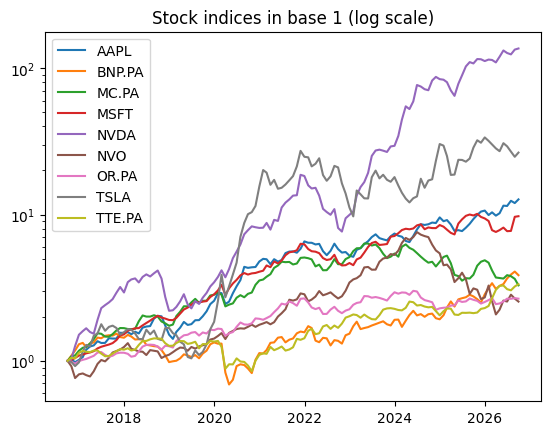

In [ ]:
monthly_prices_rebased=monthly_data['Close']/monthly_data['Close'].iloc[0]
plt.plot(monthly_prices_rebased)
plt.title('Stock indices in base 1 (log scale)')
plt.legend(monthly_prices_rebased.columns)
plt.yscale('log')
plt.savefig("stock_prices.png", dpi=300, bbox_inches="tight")
plt.show()

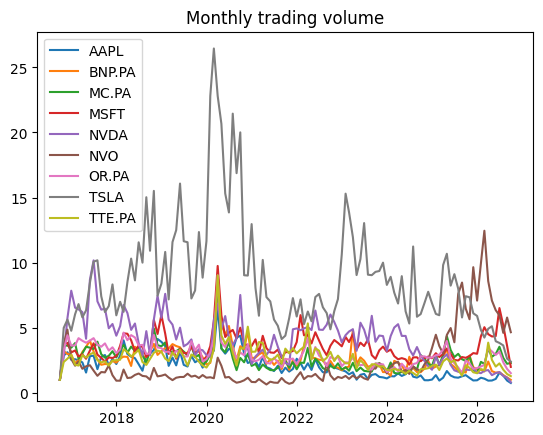

In [ ]:
monthly_volume_rebased=monthly_data['Volume']/monthly_data['Volume'].iloc[0]
plt.plot(monthly_volume_rebased)
plt.title('Monthly trading volume')
plt.legend(monthly_volume_rebased.columns)
plt.savefig("monthly_volume.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
data.to_csv('clean_data.csv', index='False')

**Exercice TO DO: Momentum Strategy on 50 Stocks**

## Objective
Explore the performance of a simple momentum strategy on a subset of 50 stocks.

## Procedure

### 1. Stock Selection
- Use `pandas` to fetch the list of all tickers from [this link](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies)
    - Use pd.read_html
- Randomly select 50 stocks from this list.

### 2. Data Collection
- For each stock, download the daily adjusted closing prices for the last 365 days.
- Store this data in a pandas DataFrame with dates as the index.

### 3. Momentum Calculation
- Define momentum as the percentage change in the stock price over the previous n days (e.g., n=21 for a month).
- Using pandas, compute the momentum for each stock for each day.
- Rank the stocks based on their momentum every day.

### 4. Strategy

1. At the beginning of each month, buy the top 10 stocks based on momentum from the previous month.
2. At the end of the month, sell all the stocks.
3. Repeat this process for each month in your dataset.

### 5. Performance Analysis

- Calculate the monthly and annualized return of this strategy.
- Compare the strategy's performance against a benchmark (e.g., S&P 500).
- Plot the cumulative returns of your strategy and the benchmark.

### 6. Risk Analysis
- Using numpy, compute the standard deviation of the monthly returns to get a measure of the strategy's risk.
- Calculate the Sharpe Ratio.

## Hints

- To get the tickers list:
```python
import requests

# URL of the Wikipedia page
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Set headers to mimic a browser
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send the HTTP request with custom headers
response = requests.get(url, headers=headers)

# Use pandas to read the HTML from the response content
tables = pd.read_html(response.text)
```

In [ ]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)

/tmp/ipykernel_1364/2158521338.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [ ]:
tickers=tables[0]['Symbol'].to_list()
tickers_subset=np.random.choice(tickers,50,replace='False')
print(tickers_subset)

['JPM' 'AVY' 'COR' 'PEP' 'MCK' 'TYL' 'ZTS' 'DOC' 'CMG' 'EMR' 'PNR' 'LUV'
 'BKR' 'PSX' 'O' 'ODFL' 'RDDT' 'PHM' 'MO' 'ORLY' 'ZTS' 'PCG' 'CLX' 'PANW'
 'FDXF' 'ADP' 'OKE' 'AMAT' 'MPC' 'TROW' 'T' 'EIX' 'DG' 'WY' 'PSX' 'ARES'
 'MPC' 'JCI' 'SNA' 'EL' 'AES' 'NRG' 'AIZ' 'BEN' 'CAH' 'RVTY' 'EG' 'F'
 'MAR' 'CHTR']


In [ ]:
data=yf.download(list(tickers_subset),period="365d")
prices=data['Close']
prices.head(10)

/tmp/ipykernel_1364/1528857089.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(list(tickers_subset),period="365d")
[*********************100%***********************]  47 of 47 completed


Ticker,ADP,AES,AIZ,AMAT,ARES,AVY,BEN,BKR,CAH,CHTR,...,PNR,PSX,RDDT,RVTY,SNA,T,TROW,TYL,WY,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-08,266.234222,9.445250,175.803909,127.521523,116.788963,154.336136,15.601662,34.065441,123.337082,321.679993,...,74.840012,88.465401,88.889999,91.401566,297.304993,24.690231,74.330856,521.679993,23.561819,140.741608
2025-04-09,283.482300,10.285443,189.018799,148.059830,134.950424,163.311188,17.399693,37.715305,128.714584,346.980011,...,82.562759,98.238785,110.860001,100.911156,316.994598,24.765079,83.489105,564.979980,25.213615,149.649445
2025-04-10,281.096558,9.509881,186.162598,136.697983,128.694397,161.106125,16.594324,35.681118,127.165474,335.470001,...,79.428459,92.389992,102.010002,92.626366,309.768341,24.952291,79.590599,557.590027,24.511127,143.265823
2025-04-11,288.147827,9.509881,185.419189,143.323257,130.561737,164.104233,16.762888,36.917198,130.017029,334.380005,...,80.754890,92.761505,101.150002,94.458572,323.038910,25.330502,82.174164,568.539978,24.492144,145.643860
2025-04-14,290.091003,9.676072,190.720779,142.917831,131.168381,166.618805,16.912725,36.800407,132.986984,340.399994,...,81.344414,93.180634,98.260002,97.206902,323.730774,25.718164,82.711258,571.809998,24.795921,146.998535
2025-04-15,286.724091,9.482183,189.566559,143.827576,133.955170,163.930145,16.828444,37.141064,132.464035,343.179993,...,80.872795,91.646980,96.459999,95.135696,323.903748,26.001820,81.099998,578.429993,24.539610,145.429428
2025-04-16,282.953217,9.195961,186.162598,136.648560,132.324799,162.624512,16.435123,37.111866,132.572571,332.500000,...,79.310555,91.989914,95.379997,93.353287,319.031769,25.547972,79.053513,569.289978,24.292788,143.031906
2025-04-17,282.125885,9.399086,184.842072,135.926712,133.879318,165.235779,16.491312,37.871037,132.917908,338.959991,...,79.202141,94.399925,96.160004,91.499763,293.509216,25.670887,79.738762,570.200012,24.501635,144.893387
2025-04-21,274.016510,9.048236,179.853470,134.047882,129.936111,163.475601,16.247829,36.790676,129.425018,322.429993,...,77.822311,92.409058,94.150002,89.456909,280.940125,24.895559,77.368179,555.530029,23.438412,143.602585


In [ ]:
momentum = prices.pct_change(periods=21)
momentum.iloc[20:25]

Ticker,ADP,AES,AIZ,AMAT,ARES,AVY,BEN,BKR,CAH,CHTR,...,PNR,PSX,RDDT,RVTY,SNA,T,TROW,TYL,WY,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-08,0.109589,0.076622,0.084237,0.209677,0.346076,0.084221,0.250900,0.042237,0.178160,0.257181,...,0.231726,0.175730,0.213072,0.012849,0.024435,0.051973,0.154354,0.078841,0.045125,0.123438
2025-05-09,0.044216,0.016088,0.012782,0.039271,0.158601,0.019780,0.127018,-0.052392,0.136221,0.157790,...,0.115677,0.075536,-0.021649,-0.098893,-0.043107,0.062920,0.028616,-0.008372,-0.013178,0.040752
2025-05-12,0.058759,0.173073,0.061738,0.215206,0.271047,0.100612,0.224040,0.032649,0.153166,0.199869,...,0.218023,0.223631,0.090187,0.059703,0.014363,0.023494,0.129610,0.013630,0.044539,0.105214
2025-05-13,0.028877,0.240275,0.067999,0.193804,0.252359,0.073374,0.205587,0.012931,0.125142,0.229529,...,0.201678,0.289484,0.115571,0.020264,-0.026326,-0.012691,0.095222,-0.001302,0.034496,0.077030


In [ ]:
momentum=momentum.dropna()
momentum.head()

Ticker,ADP,AES,AIZ,AMAT,ARES,AVY,BEN,BKR,CAH,CHTR,...,PNR,PSX,RDDT,RVTY,SNA,T,TROW,TYL,WY,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-26,0.034900,-0.000681,0.052675,0.398416,-0.129172,0.039262,0.048626,-0.105063,0.190553,-0.091996,...,0.054796,-0.017065,0.082690,0.167682,0.067100,-0.087184,0.067877,-0.026938,0.041494,-0.042652
2026-06-29,0.031005,-0.004084,0.086902,0.544743,-0.137429,0.019771,0.073467,-0.129810,0.181986,-0.007402,...,0.069676,-0.015053,0.039955,0.098696,0.063825,-0.122990,0.117841,-0.049961,0.011039,-0.064137
2026-06-30,0.017170,-0.000682,0.082699,0.606453,-0.125048,0.027161,0.083298,-0.131183,0.207114,-0.012773,...,0.082157,-0.038833,-0.013750,0.064180,0.084023,-0.165323,0.100681,-0.066071,-0.014880,-0.075042
2026-07-01,0.016165,-0.004082,0.105763,0.420673,-0.108477,0.055862,0.111889,-0.145307,0.220792,-0.019355,...,0.078813,-0.031846,0.111948,0.122563,0.100505,-0.165784,0.130709,-0.085377,0.002194,-0.065885
2026-07-02,0.055922,-0.006812,0.128618,0.230568,-0.079532,0.070046,0.107080,-0.182213,0.228757,-0.021886,...,0.076621,-0.033633,0.151008,0.133181,0.106430,-0.164773,0.150154,0.014479,-0.016236,-0.020814


In [ ]:
ranked_momentum = momentum.rank(axis=1, ascending=False)
ranked_momentum.head()

Ticker,ADP,AES,AIZ,AMAT,ARES,AVY,BEN,BKR,CAH,CHTR,...,PNR,PSX,RDDT,RVTY,SNA,T,TROW,TYL,WY,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-26,24.0,35.0,17.0,1.0,47.0,22.0,19.0,44.0,4.0,43.0,...,16.0,37.0,10.0,5.0,14.0,42.0,13.0,39.0,21.0,41.0
2026-06-29,24.0,34.0,11.0,1.0,45.0,26.0,14.0,44.0,4.0,35.0,...,15.0,37.0,21.0,9.0,17.0,42.0,7.0,40.0,29.0,41.0
2026-06-30,29.0,31.0,14.0,1.0,44.0,27.0,13.0,45.0,3.0,33.0,...,15.0,38.0,35.0,18.0,12.0,46.0,8.0,41.0,36.0,42.0
2026-07-01,31.0,35.0,14.0,1.0,44.0,24.0,13.0,45.0,2.0,37.0,...,20.0,39.0,12.0,10.0,15.0,46.0,7.0,43.0,34.0,42.0
2026-07-02,25.0,36.0,12.0,1.0,44.0,21.0,16.0,47.0,2.0,41.0,...,19.0,42.0,7.0,10.0,17.0,45.0,8.0,30.0,37.0,39.0


In [ ]:
monthly_rank=ranked_momentum.resample('MS').first()
monthly_rank.head()

Ticker,ADP,AES,AIZ,AMAT,ARES,AVY,BEN,BKR,CAH,CHTR,...,PNR,PSX,RDDT,RVTY,SNA,T,TROW,TYL,WY,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-01,24.0,35.0,17.0,1.0,47.0,22.0,19.0,44.0,4.0,43.0,...,16.0,37.0,10.0,5.0,14.0,42.0,13.0,39.0,21.0,41.0
2026-07-01,31.0,35.0,14.0,1.0,44.0,24.0,13.0,45.0,2.0,37.0,...,20.0,39.0,12.0,10.0,15.0,46.0,7.0,43.0,34.0,42.0
2026-08-01,7.0,21.0,26.0,46.0,1.0,19.0,18.0,5.0,34.0,14.0,...,45.0,2.0,47.0,24.0,32.0,3.0,39.0,38.0,10.0,17.0
2026-09-01,10.0,20.0,25.0,43.0,21.0,19.0,36.0,11.0,16.0,17.0,...,41.0,3.0,38.0,6.0,37.0,5.0,32.0,2.0,39.0,22.0


In [ ]:
top10_tickers=monthly_rank.apply(lambda row:row.nsmallest(10).index.tolist(),axis=1)
top10_tickers.head()

,0
Date,
2026-06-01,"[AMAT, PANW, LUV, CAH, RVTY, PHM, DG, JPM, DOC..."
2026-07-01,"[AMAT, CAH, LUV, PANW, CMG, DOC, TROW, PHM, JP..."
2026-08-01,"[ARES, PSX, T, MPC, BKR, EMR, ADP, DG, F, WY]"
2026-09-01,"[MPC, TYL, PSX, EL, T, RVTY, MCK, OKE, COR, ADP]"
